In [1]:
#options: 'targets', 'tces', 'FTL'
cases='FTL'
#Choose the time in ours between 1, 0.5, or 2
sgCDPP_duration=2
directory = f'Output_{cases}/'

In [2]:
import re, os, csv

labels = ['TICID', 'median_bkg_diff', 'magnitude', 'flux', 'flux_err_up', 
          'flux_err_down', 'crowding', 'unnorm_test_mean', 'unnorm_test_err',
          'SPOC_sgCDPP_duration', 'SPOC_sgCDPP', 'SPOC_sgCDPP_norm', 
          'QLP_sgCDPP_duration', 'QLP_sgCDPP', 'QLP_sgCDPP_norm', 
          'SPOC_sgCDPP2_duration', 'SPOC_sgCDPP2', 'SPOC_sgCDPP3_duration',
          'SPOC_sgCDPP3', 'QLP_sgCDPP2_duration', 'QLP_sgCDPP2',
          'QLP_sgCDPP3_duration', 'QLP_sgCDPP3', 'SPOC_CDPP_period',
          'SPOC_CDPP', 'SPOC_CDPP2_duration', 'SPOC_cDPP2']
endline_marker='0.5h CDPP:'

with open(directory+'output_data.csv',"w",newline='') as csvfile:
    writer = csv.writer(csvfile)
    # Write the header row
    writer.writerow(labels)
    for root, dirs, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            if 'output.log' in file_path and os.path.getsize(file_path)>0:
                with open(file_path, "r") as fr:
                    text = fr.read()             
                    if endline_marker in text:
                        TICid = re.findall(r'TIC\d+', text)
                        pattern = r"[-+]?\d*\.?\d+|nan"
                        quantities = re.findall(pattern, text)
                        [TIC, median_back_diff, mag, flux, fl_err_up, fl_err_do, 
                         crowd, test, test_err, SPOC_sgCDPP_period, 
                         SPOC_sgCDPP, SPOC_sgCDPP_norm, QLP_sgCDPP_period,
                         QLP_sgCDPP, QLP_sgCDPP_norm, SPOC_sgCDPP2_period,
                         SPOC_sgCDPP2, SPOC_sgCDPP3_period, SPOC_sgCDPP3,
                         QLP_sgCDPP2_period, QLP_sgCDPP2, QLP_sgCDPP3_period,
                         QLP_sgCDPP3, SPOC_CDPP_period, SPOC_CDPP,
                         SPOC_CDPP2_period, SPOC_cDPP2] = quantities                
                        writer.writerow(quantities)

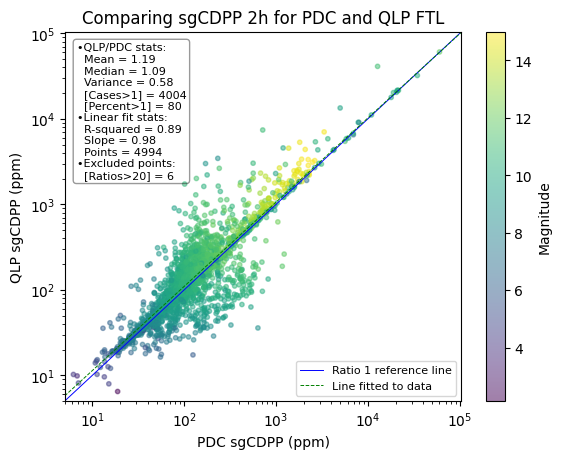

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import statistics as stats
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

outlier_treshold=20

fontsize=8
linewidth=0.7

# Read the CSV file, specifying the columns you want to read
if sgCDPP_duration==1:
    df = pd.read_csv(directory+'output_data.csv', 
                     usecols=['magnitude', 'SPOC_sgCDPP', 'QLP_sgCDPP'])
    x=df['SPOC_sgCDPP']
    y=df['QLP_sgCDPP']
elif sgCDPP_duration==0.5:
    df = pd.read_csv(directory+'output_data.csv', 
                     usecols=['magnitude', 'SPOC_sgCDPP2', 'QLP_sgCDPP2'])
    x=df['SPOC_sgCDPP2']
    y=df['QLP_sgCDPP2']
elif sgCDPP_duration==2:
    df = pd.read_csv(directory+'output_data.csv', 
                     usecols=['magnitude', 'SPOC_sgCDPP3', 'QLP_sgCDPP3'])
    x=df['SPOC_sgCDPP3']
    y=df['QLP_sgCDPP3']
    
z=df['magnitude']

# Create a mask to ignore values less than or equal to 0
condition1=y/x < outlier_treshold 
condition2=x/y < outlier_treshold
mask = condition1 & condition2

# Apply the mask to the data
x = x[mask]
y = y[mask]
z = z[mask]

sgCDPP_ratio=y/x

mean = stats.mean(sgCDPP_ratio)
median = stats.median(sgCDPP_ratio)
variance = stats.variance(sgCDPP_ratio)

counts=0
for ratio in sgCDPP_ratio:
    if ratio>1:
        counts=counts+1

# Plot the data
plt.scatter(x, y, c=z, s=10, alpha=0.5, cmap='viridis')
plt.xlabel('PDC sgCDPP (ppm)')
plt.ylabel('QLP sgCDPP (ppm)')
plt.title(f'Comparing sgCDPP {sgCDPP_duration}h for PDC and QLP {cases}')
ax=plt.gca()
ax.set_xscale("log");
ax.set_yscale("log");
#plt.plot([min(x), max(x)], [min(y), max(y)], 'r--')
ax.axline((0, 0), (1, 1), color='blue', linestyle='-', linewidth=linewidth,
          label='Ratio 1 reference line')
plt.xlim(5, None)
plt.ylim(5, None)
cbar=plt.colorbar()
cbar.set_label('Magnitude')

# Convert df to numpy array
x_arr = x.to_numpy()
y_arr = y.to_numpy()

#Linear regression in log space
log_x = np.log(x_arr)
log_y = np.log(y_arr)
model = LinearRegression()
model.fit(log_x.reshape(-1, 1), log_y)  # Reshape log_x to a 2D array

intercept = model.intercept_
slope = model.coef_[0]

log_y_pred = model.predict(log_x.reshape(-1, 1))
y_pred = np.exp(log_y_pred)

# Calculate R-squared as a goodness-of-fit test
r2 = r2_score(y_arr, model.predict(x_arr.reshape(-1, 1)))

# Get the x and y limits of the plot
x_lim = ax.get_xlim()
y_lim = ax.get_ylim()

#Extend linear model to the edges of the plot
x_arr[0] = x_lim[0]
log_x[0] = np.log(x_arr[0])
log_y_pred = model.predict(log_x[0].reshape(-1, 1))[0]
y_pred[0] = np.exp(log_y_pred)

x_arr[-1] = x_lim[1]
log_x[-1] = np.log(x_arr[-1])
log_y_pred = model.predict(log_x[-1].reshape(-1, 1))[-1]
y_pred[-1] = np.exp(log_y_pred)

plt.plot(x_arr, y_pred, color='green', linewidth=linewidth, linestyle='--',
         label='Line fitted to data')
plt.legend(fontsize=fontsize, loc='lower right')

# Add a text box
textstr = f"""•QLP/PDC stats:
  Mean = {mean:.2f}
  Median = {median:.2f}
  Variance = {variance:.2f}
  [Cases>1] = {counts}
  [Percent>1] = {(counts/len(x))*100:.0f}
•Linear fit stats:
  R-squared = {r2:.2f}
  Slope = {slope:.2f}
  Points = {len(x)}
•Excluded points:
  [Ratios>{outlier_treshold}] = {(~mask).sum()}"""

props = dict(boxstyle='round', facecolor='None', alpha=0.4)
ax.text(0.03, 0.97, textstr, transform=ax.transAxes, fontsize=fontsize,
        verticalalignment='top', bbox=props)

#Save and show
plt.savefig(
    directory+'Figures/'+\
    f'PDC-QLP_sgCDPP_{sgCDPP_duration}h_{cases}_comparison.pdf')
plt.show()

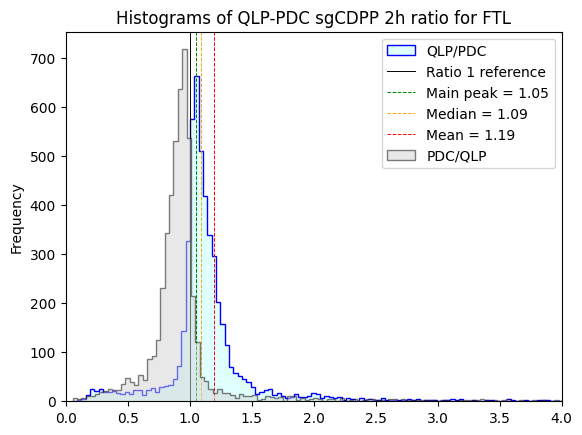

In [4]:
from scipy.signal import find_peaks

bins=500

# Create histogram and get bin counts and edges
hist, bin_edges = np.histogram(sgCDPP_ratio, bins=bins)

# Find peaks in the histogram
peaks, _ = find_peaks(hist)

# Get the bin with the maximum count (main peak)
main_peak_index = np.argmax(hist)

# Get x-coordinate (bin center) of the main peak
main_peak_x = (bin_edges[main_peak_index] + bin_edges[main_peak_index + 1]) / 2

sgCDPP_ratio.plot.hist(bins=bins, histtype='step', fill=True, 
                       facecolor='lightcyan', edgecolor='blue', label='QLP/PDC')
plt.title(f'Histograms of QLP-PDC sgCDPP {sgCDPP_duration}h ratio for {cases}')
plt.xlabel('QLP-PDC sgCDPP ratios')
plt.ylabel('Frequency')
plt.axvline(x=1, color='black', linestyle='-', linewidth=linewidth,
          label='Ratio 1 reference')
plt.axvline(x=main_peak_x, color='green', linestyle='--', linewidth=linewidth,
          label=f'Main peak = {main_peak_x:.2f}')
plt.axvline(x=median, color='orange', linestyle='--', linewidth=linewidth,
          label=f'Median = {median:.2f}')
plt.axvline(x=mean, color='red', linestyle='--', linewidth=linewidth,
          label=f'Mean = {mean:.2f}')
(1/sgCDPP_ratio).plot.hist(bins=bins, histtype='step', fill=True,
                           facecolor='lightgray',edgecolor='black',
                           alpha=0.5, label='PDC/QLP')
plt.xlim(0,4)
plt.legend()
plt.savefig(
    directory+'Figures/'+\
    f'PDC-QLP_sgCDPP_{sgCDPP_duration}h_{cases}_comparison_histogram.pdf')
plt.show()